### Roll No : 1200187
### Name : Rageshwer Singh
## Course : Feature Engineering - Assignment
#### Trimester - 1 (MSc Data Science and AI)
The objective of the assignment is to implement feature engineering and prepare the raw dataset for the machine learning models.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import RobustScaler,OrdinalEncoder,OneHotEncoder,MinMaxScaler,StandardScaler
mm=MinMaxScaler((1,100))
ss=StandardScaler()
from sklearn.feature_selection import mutual_info_classif
from  statsmodels.stats.outliers_influence import variance_inflation_factor



df=pd.read_excel('Graded Assignment 1 Dataset.xlsx')
df2=df.copy()
print("Importing the libraries required.")

Importing the libraries required.


# 1. Task : EDA and Understanding of the dataset.

## 1.1 Exploring features:

In [2]:
# Exploring the dataset
df.info()
# Separating the numeric and categorical features :
num_col=df.select_dtypes(include=['number']).columns
cat_col=df.select_dtypes(include=['string','object']).columns
print(f"The numeric columns in the dataset : {num_col.values}")
print("="*100)
print(f"The categorical columns in the dataset : {cat_col.values}")

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2375 non-null   float64
 1   income                    2500 non-null   float64
 2   credit_score              2300 non-null   float64
 3   loan_amount               2500 non-null   float64
 4   monthly_spend             2500 non-null   float64
 5   experience_years          2500 non-null   int64  
 6   employment_type           2375 non-null   str    
 7   education_level           2500 non-null   str    
 8   region                    2500 non-null   str    
 9   risk_tolerance            2500 non-null   str    
 10  financial_capacity_index  2500 non-null   float64
 11  household_cashflow_score  2500 non-null   float64
 12  behavior_score            2500 non-null   float64
 13  loan_default              2500 non-null   int64  
dtypes: float64(8), int6

## 1.2 Numeric Features :

In [3]:
# Statistical information of the numerical columns :
df[num_col].describe()
# We can see the min and max values in the features and have an idea about the range of values in the dataset

,age,income,credit_score,loan_amount,monthly_spend,experience_years,financial_capacity_index,household_cashflow_score,behavior_score,loan_default
count,2375.000000,2500.000000,2300.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,38.617037,26864.999724,677.513832,20102.542603,4013.070946,17.124000,26.071650,26.697079,50.014697,0.186000
std,11.375320,20091.626397,71.032915,7890.874475,3663.282652,10.101477,17.361648,18.272229,9.905279,0.389185
min,18.000000,3274.687462,454.528855,1000.000000,200.244019,0.000000,3.274687,-9.138941,13.923345,0.000000
25%,30.462617,14411.106577,629.316557,14771.636109,1755.975077,9.000000,14.390371,15.069634,43.327227,0.000000
50%,38.344938,22052.298380,677.143115,20089.633564,2926.958460,17.000000,21.926530,23.135050,50.013543,0.000000
75%,46.184030,32894.193900,726.449956,25374.566413,4986.269855,26.000000,32.486876,34.008478,56.435018,0.000000
max,75.000000,265497.957871,850.000000,47019.063353,44454.194148,34.000000,232.290175,233.565716,83.891124,1.000000


<Axes: >

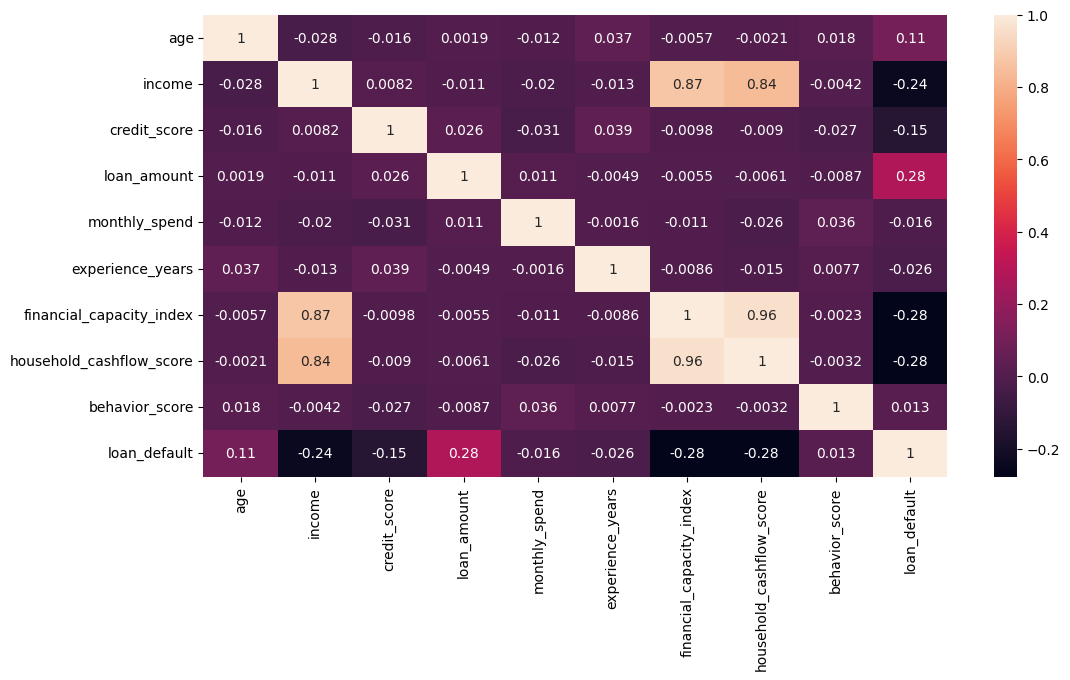

In [4]:
# Correlation of numerical features with each other and the target variable :
plt.figure(figsize=(12,6))
sns.heatmap(df[num_col].corr(),annot=True)

As it is clear from the map 'Income' feature has high correlation with 'financial_capacity_index' and 'household_cashflow_score'. The 'financial_capacity_index' and 'household_cashflow_score' have high correlation of 0.96. Both these features indirectly show the financial strength of the individual and are highly derivable from the 'income'.

## 1.3 Categorical Features :

In [5]:
# Lets see the proportion of data points in each level of categorical data attributes:
emp_type=df['employment_type'].value_counts(),
edu_level=df['education_level'].value_counts(),
risk_tol=df['risk_tolerance'].value_counts()
reg=df['region'].value_counts()
print(emp_type)
print(edu_level)
print(risk_tol)
print(reg)

(employment_type
salaried         1306
self_employed     482
unemployed        355
student           232
Name: count, dtype: int64,)
(education_level
bachelor       961
high_school    908
master         494
phd            137
Name: count, dtype: int64,)
risk_tolerance
low       999
medium    997
high      504
Name: count, dtype: int64
region
east     662
north    628
south    613
west     597
Name: count, dtype: int64


### 1.3.1 Plotting the percentage of defaulted individuals in each subcategory :

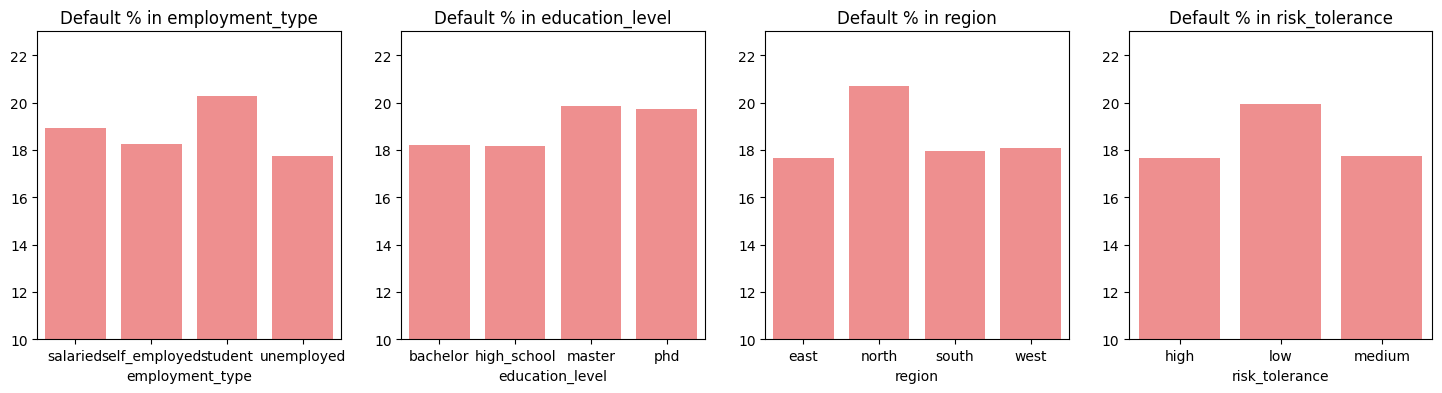

In [6]:
# Plotting what percentage of people default in each category and subcategory of attributes :

fig,ax=plt.subplots(1,4,figsize=(18,4))

index=0
for i in range(4):
   
    if index<=4:
        total_series=df[cat_col[index]].value_counts().sort_index()                                                 # sort index makes sure both series have same order by label of values
        default_series=df.groupby('loan_default').get_group(1)[cat_col[index]].value_counts().sort_index()
        sub_cat=total_series.index
        perct=[default_series.loc[i]/total_series.loc[i]*100 for i in sub_cat]
        sns.barplot(x=sub_cat,y=perct,ax=ax[i],color='r',alpha=0.5)
        ax[i].set_title(f"Default % in {cat_col[index]}")
        ax[i].set_ylim(10,23)
        index+=1

As shown in the plot, the default percentage of people accross categories and subcategories do not show much variation (~19%). This means that the values of these features (subcategories) alone do not make significant effects on the target variable. 

## 1.2 Missing Values

In [7]:
# Missing values :
missing=df.isna().sum().sort_values(ascending=False)
print(f"The attributes that have missing values in them :\n{missing[missing>0]}")

The attributes that have missing values in them :
credit_score       200
age                125
employment_type    125
dtype: int64


<Axes: >

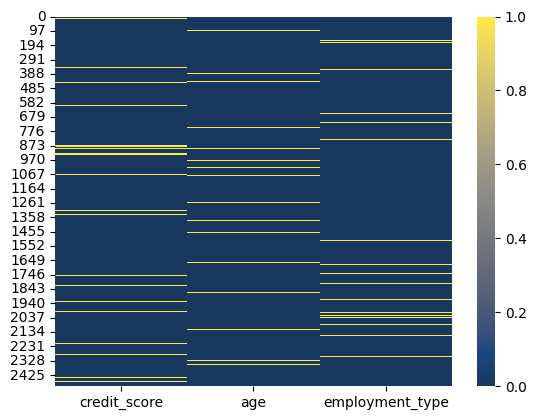

In [8]:
# Visualizing the missing values
sns.heatmap(df[['credit_score','age','employment_type']].isna(),alpha=0.9,cmap='cividis')

## 1.3 Feature Distributions : 

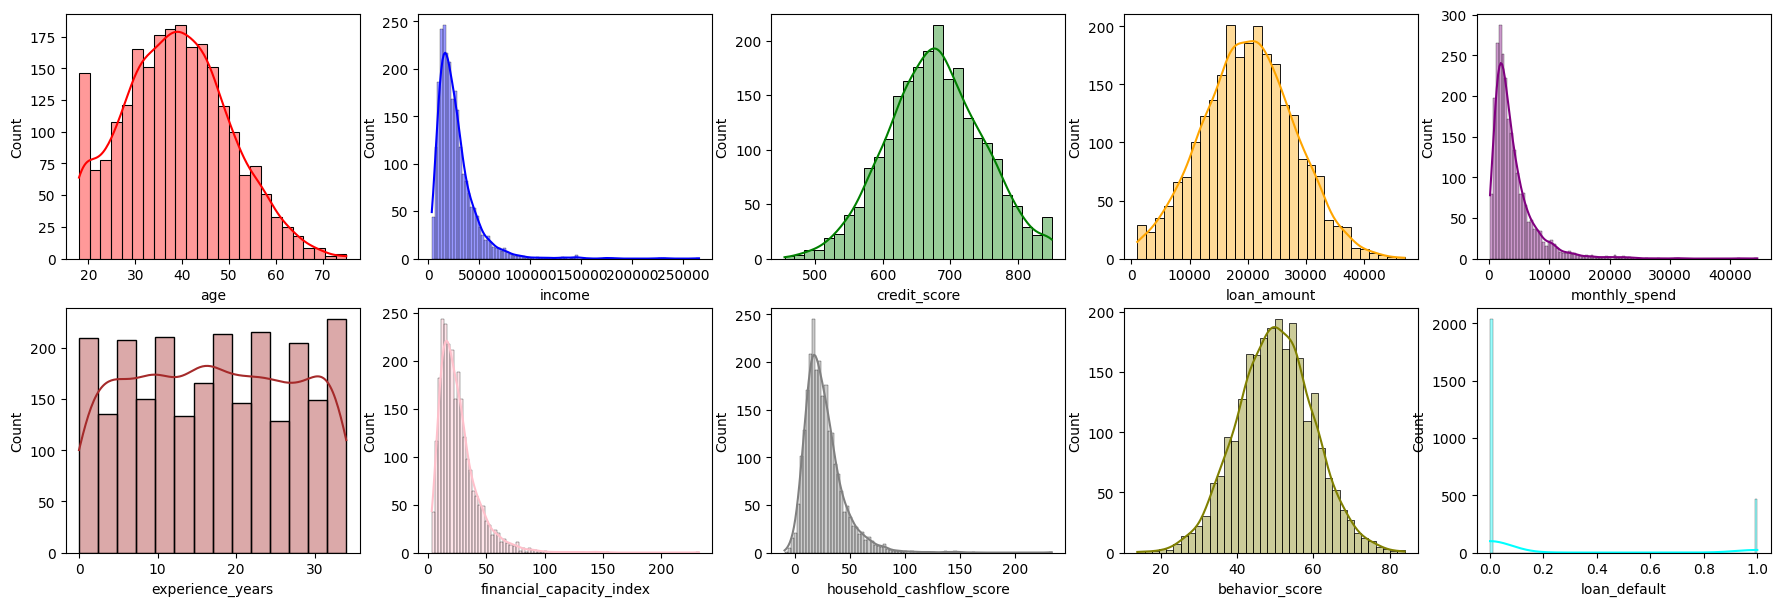

In [9]:
# Visualizing the distributions of the numeric variables:
# There are a total of 9 numeric columns (one target variable)
fig,ax=plt.subplots(2,5,figsize=(22,7))
colors = ['red','blue','green','orange','purple',
          'brown','pink','gray','olive','cyan']
index=0
for i in range(2):
    for j in range(5):
        if index <=10:
            sns.histplot(df[num_col[index]],kde=True,ax=ax[i][j],color=colors[index],alpha=0.4)
            index+=1
        else : 
            ax[i][j].axis('off')


We can see that [income, monthly spend, financial capacity index and house hold cash flow score] has extreme right skewness.

# 2. Data Cleaning

## 2.1 Handling missing values:

In [10]:
# Only 3 columns have missing values, out of which 2 are numeric (age,credit_score) and 1 categorical(employment_type)
print(missing[missing>0])

credit_score       200
age                125
employment_type    125
dtype: int64


### 2.1.1 Handling 'age':

In [11]:
df['age'].describe()

count    2375.000000
mean       38.617037
std        11.375320
min        18.000000
25%        30.462617
50%        38.344938
75%        46.184030
max        75.000000
Name: age, dtype: float64

In [12]:
# There is not much difference in the mean age of defaulters and regular:
print(f"The mean age of people that defaulted :{df[df['loan_default']==1]['age'].mean()}")
print(f"The mean age of people that did not default :{df[df['loan_default']==0]['age'].mean()}")

# Imputing mean at missing places
mean_age=df['age'].mean()
def age_missing(x):
    if pd.isnull(x):
        return mean_age
    else :
        return x
df['age']=df['age'].apply(age_missing)


The mean age of people that defaulted :41.16638195830161
The mean age of people that did not default :38.04057239587469


### 2.1.2 Handling 'credit_score':

In [13]:
# No strong correlarion with other features
print(df['credit_score'].describe())
mean_cs=df['credit_score'].mean()
med_cs=df['credit_score'].median()
print(f"\nThe mean of the credit score : {mean_cs} and the median : {med_cs}")
# The mean and median do not deviate much
# Let us explore if there is a difference in mean/median of credit scores for defaulters and regular people
print(f"The mean CS of people that defaulted :{df[df['loan_default']==1]['credit_score'].mean()} and median : {df[df['loan_default']==1]['credit_score'].median()}")
print(f"The mean CS of people that did not default :{df[df['loan_default']==0]['credit_score'].mean()} and median : {df[df['loan_default']==0]['credit_score'].median()}")

count    2300.000000
mean      677.513832
std        71.032915
min       454.528855
25%       629.316557
50%       677.143115
75%       726.449956
max       850.000000
Name: credit_score, dtype: float64

The mean of the credit score : 677.5138321140574 and the median : 677.1431154800446
The mean CS of people that defaulted :655.601548778555 and median : 654.854613784219
The mean CS of people that did not default :682.4376785291704 and median : 681.593732625659


Before the loan is classified as NPA, it is classified into SMA (Special Mention Accounts) categories for 90 days. Before NPA, the credit score is dropped due to the missed installments and loan account moving into SMA status. So, naturally the defaulted credit scores will be lesser than the regular loan accounts. Hence, we can replace the missing values with the mean of defaulted or regular in the credit score column.

In [14]:
# Filling missing values with respective means
mean_no_def_cs=df[df['loan_default']==0]['credit_score'].mean()
mean_def_cs=df[df['loan_default']==1]['credit_score'].mean()
df.loc[(df['loan_default']==0) & (df['credit_score'].isnull()),'credit_score']=mean_no_def_cs
df.loc[(df['loan_default']==1) & (df['credit_score'].isnull()),'credit_score']=mean_def_cs

### 2.1.3 Handling 'employment_type':

In [15]:
# As seen from the correlation heatmap, there is no relationship between incomes or education_level with employment_type
# We will be inducing the employment_types based on their proportion:
unique_et=df['employment_type'].value_counts(normalize=True).sort_index()
print(unique_et)

employment_type
salaried         0.549895
self_employed    0.202947
student          0.097684
unemployed       0.149474
Name: proportion, dtype: float64


In [16]:
# There are 125 missing values in the column
np.random.seed(42)
arr_et=np.random.choice(unique_et.sort_index().index,125,p=unique_et.sort_index().values)
df.loc[df['employment_type'].isna(),'employment_type']=arr_et

## 2.2 Outlier detection

Text(0.5, 0, '')

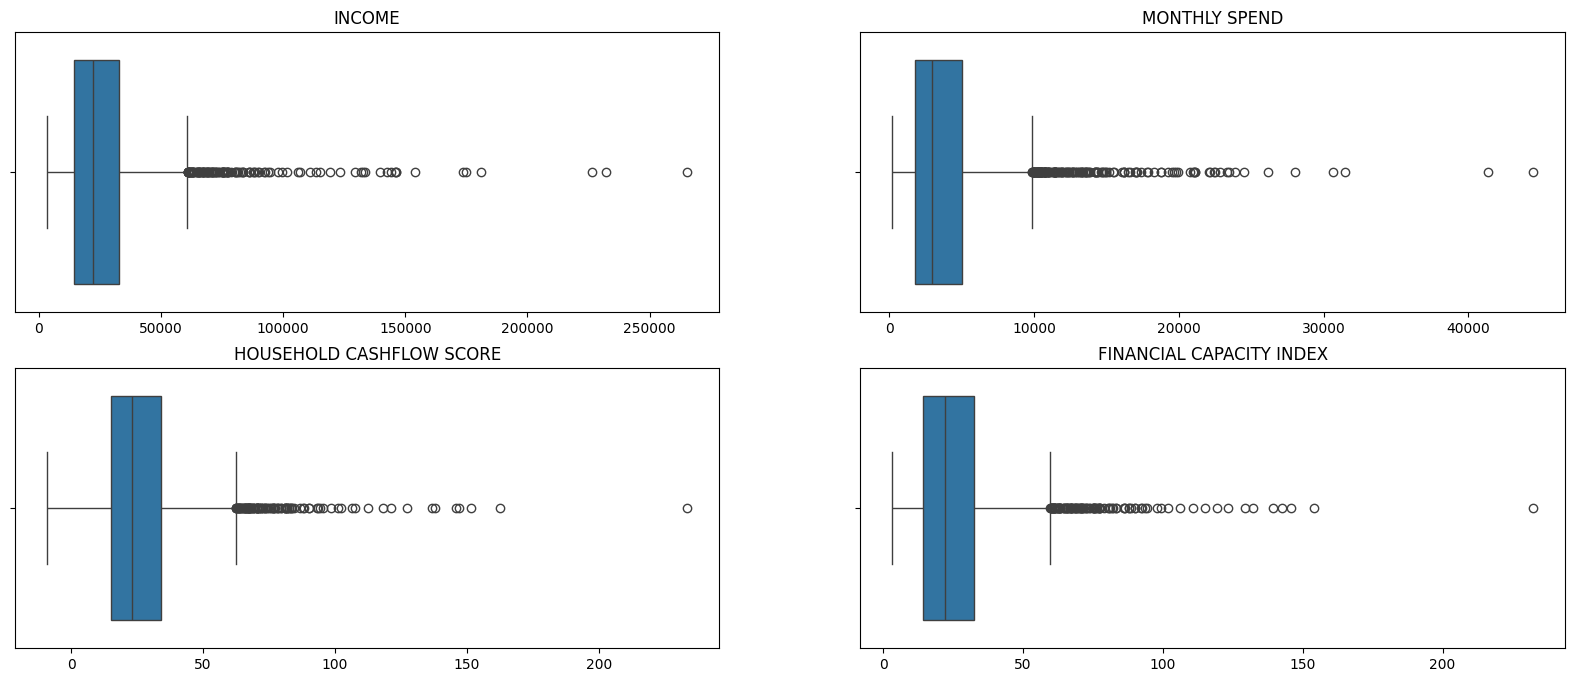

In [17]:
# The income column is highly positively skewed and has the maximum amount as : 2.64L
# The values are kept as these are genuine data points and show real world variation and difference in income of individuals
fig,ax=plt.subplots(2,2,figsize=(20,8))
sns.boxplot(df['income'],orient='h',ax=ax[0][0])
sns.boxplot(df['monthly_spend'],orient='h',ax=ax[0][1])
sns.boxplot(df['household_cashflow_score'],orient='h',ax=ax[1][0])
sns.boxplot(df['financial_capacity_index'],orient='h',ax=ax[1][1])
ax[0][0].set_title("INCOME")
ax[0][1].set_title("MONTHLY SPEND")
ax[1][0].set_title("HOUSEHOLD CASHFLOW SCORE")
ax[1][1].set_title("FINANCIAL CAPACITY INDEX")
ax[0][0].set_xlabel("")
ax[0][1].set_xlabel("")
ax[1][0].set_xlabel("")
ax[1][1].set_xlabel("")

All the three columns are highly related with income and hence the outliers. Winsorization or capping these values will result in loss of data as these are actual skewed data points. They are kept.

# 3. Feature Transformation and Encoding

## 3.1 Numeric Features Transformation: 

### 3.1.1 Transforming the income and monthly_spend using log transformation:
Std and MinMax Scaling the data does not change the shape of distribution, it only changes the range as it is sensitive to outliers. The log transformation changes the shape by compressing the larger values more.

<Axes: ylabel='Count'>

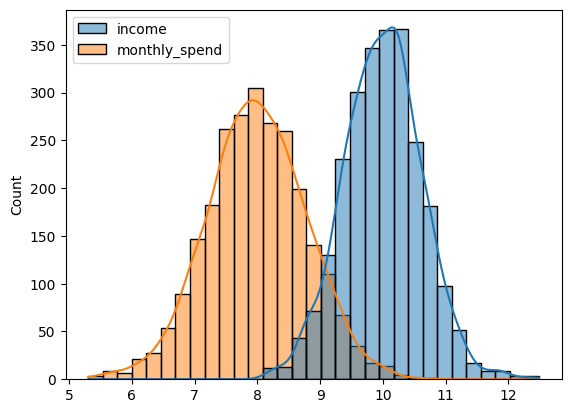

In [18]:
df[['income','monthly_spend']]=np.log1p(df[['income','monthly_spend']])
sns.histplot(df[['income','monthly_spend']],kde=True)
# As seen in the plot below, now the values in these columns are normally distributed and not skewed

### 3.1.2 Transforming household_cashflow_score and financial_capacity_index using robust scaling:
Applying log transformation to these values will result in very small data points as the range of these values is less. So, robust scaling is applied. It uses the median and IQR to scale data.

In [19]:
rs=RobustScaler()
df[['household_cashflow_score','financial_capacity_index']]=rs.fit_transform(df[['household_cashflow_score','financial_capacity_index']])

### 3.1.3 Smoothing of 'Experience'
The experience in years is very distorted, so it can be smoothed using bins.

(-50.0, 50.0)

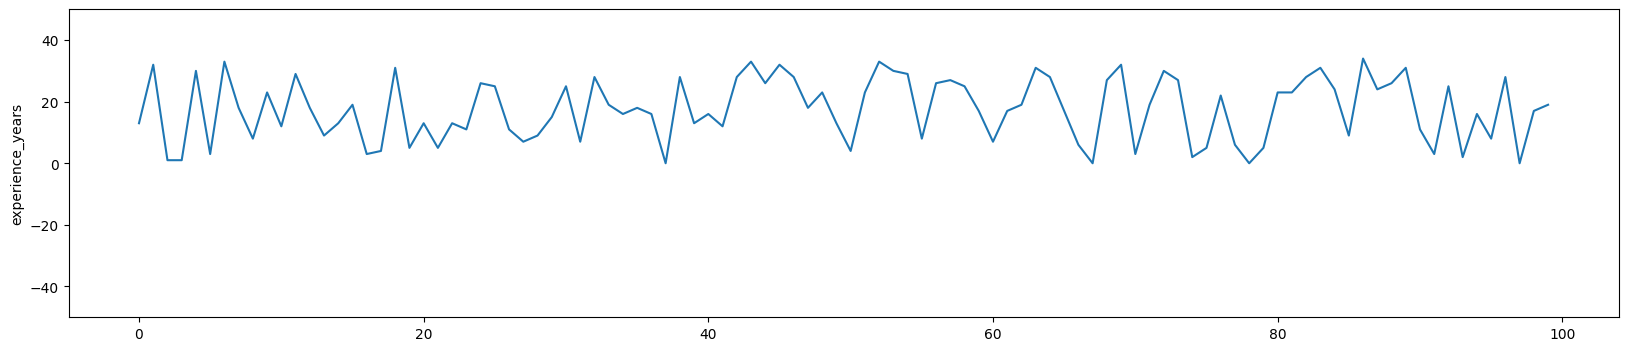

In [20]:
plt.figure(figsize=(20,4))
sns.lineplot(df['experience_years'].head(100))
plt.ylim(-50,50)

(-50.0, 50.0)

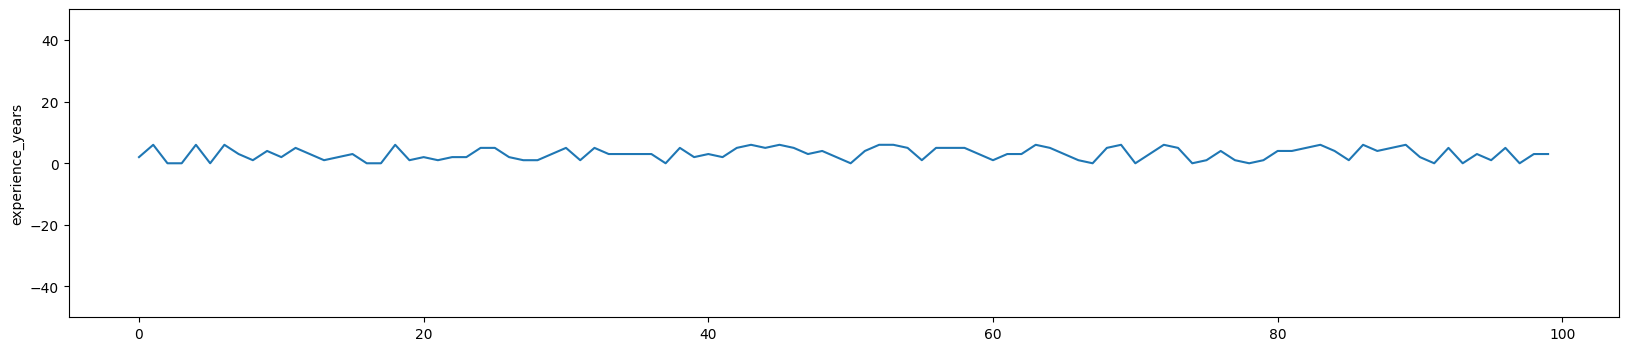

In [21]:
# experience ranges from 0-34 years, so, we can make 7 bins of ~5yrs each
df['experience_years']=pd.cut(df['experience_years'],bins=7,labels=False)
plt.figure(figsize=(20,4))
sns.lineplot(df['experience_years'].head(100))
plt.ylim(-50,50)
# Smoothing it further will result in loss of data

## 3.2 Encoding Categorical Attributes :

### 3.2.1 Encoding education_level and risk_tolerance using Ordinal Encoding:
Since these categories show order/rank, these can be easily encoded.

In [22]:
# Encoding :
oe=OrdinalEncoder(categories=[
    ['high_school','bachelor','master','phd'],
    ['low','medium','high']
])

df[['education_level','risk_tolerance']]=oe.fit_transform(df[['education_level','risk_tolerance']])

### 3.2.1 One hot encoding the 'region':
Using labels or integers might unintensionally specify order, so the best case is to one hot encode it.

In [23]:
# Encoding the 'region':
ohe=OneHotEncoder(sparse_output=False)
encoded_reg=ohe.fit_transform(df[['region']])
encoded_df=pd.DataFrame(encoded_reg,columns=ohe.get_feature_names_out())
df=pd.concat([df,encoded_df],axis=1)

### 3.2.3 Encoding Employment type :

In [24]:
temp1=df.groupby('employment_type')['income'].mean()
temp2=df.groupby('employment_type')['education_level'].mean()
temp3=df.groupby('employment_type')['financial_capacity_index'].mean()
print(temp1,temp2,temp3)

employment_type
salaried         10.009715
self_employed     9.997006
student           9.958615
unemployed        9.991451
Name: income, dtype: float64 employment_type
salaried         0.920232
self_employed    0.958084
student          1.024291
unemployed       0.959786
Name: education_level, dtype: float64 employment_type
salaried         0.231960
self_employed    0.227479
student          0.180748
unemployed       0.252430
Name: financial_capacity_index, dtype: float64


The income and other related columns cannot be a justification of the employment status. A self employed individual can earn much more or much less or equal to a salaried person and vice versa. Same can be said for students earning part-time equal to some self employed, salaried or unemployed individuals. This can be seen in the above distribution of means that there is no effect of employment status on either of income,education level and financial capacity index. So, One hot encoding is applied on this too.

In [25]:
ohe=OneHotEncoder(sparse_output=False)
encoded_et=ohe.fit_transform(df[['employment_type']])
encoded_etdf=pd.DataFrame(encoded_et,columns=ohe.get_feature_names_out())
df=pd.concat([df,encoded_etdf],axis=1)

# 4. Feature Construction

## 4.1 EMI NMI ratio:
The EMI ratio is a measure of a person's installments to his earnings. Since we do not have a monthly loan repayment amount, and the max loan amount is ~50,000/-, for which assuming the repayment tenure of 1 year is sufficient, so, we can calculate the EMI NMI ratio by taking his/her yearly earnings.

In [26]:
# since we log transformed the income attribute before, to capture the real variatios, i am using the df2 (copy made at the start with actual data values):
df['emi_ratio']=df2['loan_amount']/((df2['income'])*12)        # taking annual income in consideration
df.drop(['region','employment_type'],axis=1).corr().loc['loan_default']
# As we can see the correlation of loan default with EMI ratio is 0.46

age                              0.103552
income                          -0.344342
credit_score                    -0.153134
loan_amount                      0.275734
monthly_spend                   -0.025074
experience_years                -0.020218
education_level                  0.015209
risk_tolerance                  -0.024587
financial_capacity_index        -0.277489
household_cashflow_score        -0.275211
behavior_score                   0.012528
loan_default                     1.000000
region_east                     -0.014287
region_north                     0.031269
region_south                    -0.009601
region_west                     -0.007335
employment_type_salaried         0.009314
employment_type_self_employed   -0.005614
employment_type_student          0.007090
employment_type_unemployed      -0.012632
emi_ratio                        0.465096
Name: loan_default, dtype: float64

## 4.2 Difference in buffer and loan amount
If (income - expenses = buffer), then the difference in loan amount and this buffer can directly affect the default status. If a person has more buffer, he/she is likely to keep the loan regular. Calculating (loan amount - savings or buffer) gives a corr score of 0.47<br>
Thought:<br>
if buffer > loan : our term comes out to be 0<br>
if buffer < loan : our term comes out the difference b/w loan and buffer, higher the difference, more chances for default.

In [27]:
# Using the copy df for actual values and not scaled
df['buffer']=np.maximum(df2['loan_amount']-(df2['income']-df2['monthly_spend']),0)
df.drop(['region','employment_type'],axis=1).corr().loc['loan_default']

age                              0.103552
income                          -0.344342
credit_score                    -0.153134
loan_amount                      0.275734
monthly_spend                   -0.025074
experience_years                -0.020218
education_level                  0.015209
risk_tolerance                  -0.024587
financial_capacity_index        -0.277489
household_cashflow_score        -0.275211
behavior_score                   0.012528
loan_default                     1.000000
region_east                     -0.014287
region_north                     0.031269
region_south                    -0.009601
region_west                     -0.007335
employment_type_salaried         0.009314
employment_type_self_employed   -0.005614
employment_type_student          0.007090
employment_type_unemployed      -0.012632
emi_ratio                        0.465096
buffer                           0.479047
Name: loan_default, dtype: float64

## 4.3 Credit Score, FCI and Loan amount:
If the person has low credit score with low financial capacity index and high loan amount, then he/she is more susceptable to default. The difference from highest possible score when multiplied by the reciprocal of FCI, punishes the data point with high scores. When multiplied with the loan amount given, it gives a feature that has high value for : low credit score + low FCI + high amount. This gives the Pearson's coefficient score of 0.50 

In [28]:
# Using df['credit_score] instead of df2 because of missing values in credit scores. In df, we have already handled the missing values.
# And in df, loan amount is already transformed
df['cs_fci_ln']=(900-df['credit_score'])*(1/df2['financial_capacity_index'])*df['loan_amount']
df.drop(['region','employment_type'],axis=1).corr().loc['loan_default']

age                              0.103552
income                          -0.344342
credit_score                    -0.153134
loan_amount                      0.275734
monthly_spend                   -0.025074
experience_years                -0.020218
education_level                  0.015209
risk_tolerance                  -0.024587
financial_capacity_index        -0.277489
household_cashflow_score        -0.275211
behavior_score                   0.012528
loan_default                     1.000000
region_east                     -0.014287
region_north                     0.031269
region_south                    -0.009601
region_west                     -0.007335
employment_type_salaried         0.009314
employment_type_self_employed   -0.005614
employment_type_student          0.007090
employment_type_unemployed      -0.012632
emi_ratio                        0.465096
buffer                           0.479047
cs_fci_ln                        0.501197
Name: loan_default, dtype: float64

# 5. Feature Selection

In [29]:
# We have applied pearson's correlation in the feature construction part to get new relevant features
# Removing the features that are redundant :
df=df.drop(['region','employment_type'],axis=1)
# Also removing one region type and employment type, because they affect the VIF scores for multicollinearity.
df=df.drop(['region_east','employment_type_unemployed'],axis=1)

## 5.1 Mutual Information Classifier
The mutual information shows how much information one variable holds about the target. It does not blindly depend on linear relationship, but looks for all kinds of patterns. We have picked MIC over Fisher score because, FS depends upon the variation between and within classes. And we have seen in above plots and pearson's correlation in feature construction, the means of income, household_score and financial_capacity_index do not vary much. The between class and within class variation in the key features will be almost similar.

In [30]:
x=df.drop(['loan_default'],axis=1)
y=df['loan_default']
feat=df.drop(['loan_default'],axis=1).columns
mic_score=mutual_info_classif(x.values,y.values,discrete_features='auto')
mic_df=pd.DataFrame({
    'MIC_Score':mic_score,
    'Features':feat.values
})
mic_=mic_df.sort_values(by='MIC_Score',ascending=False)
print(mic_)

    MIC_Score                       Features
17   0.134751                      emi_ratio
19   0.133559                      cs_fci_ln
18   0.110529                         buffer
8    0.076257       financial_capacity_index
1    0.074536                         income
9    0.064447       household_cashflow_score
3    0.046256                    loan_amount
2    0.044248                   credit_score
12   0.011636                   region_south
0    0.010605                            age
6    0.008779                education_level
11   0.007108                   region_north
16   0.006808        employment_type_student
14   0.004216       employment_type_salaried
10   0.001568                 behavior_score
7    0.000000                 risk_tolerance
13   0.000000                    region_west
15   0.000000  employment_type_self_employed
5    0.000000               experience_years
4    0.000000                  monthly_spend


## 5.2 Spearman's Coefficient

In [31]:
# Spearman's Coefficient
spearman=df.corr(method='spearman').loc['loan_default']
spearman=spearman.drop('loan_default')
spearman=spearman[abs(spearman.values)>0.01]
print(spearman.sort_values(ascending=False))

cs_fci_ln                   0.469952
buffer                      0.457869
emi_ratio                   0.447552
loan_amount                 0.274143
age                         0.085641
region_north                0.031269
education_level             0.014616
behavior_score              0.010047
experience_years           -0.020133
monthly_spend              -0.023353
risk_tolerance             -0.025614
credit_score               -0.158319
household_cashflow_score   -0.337393
income                     -0.358214
financial_capacity_index   -0.362791
Name: loan_default, dtype: float64


In [32]:
# After looking at the top features by each method, following features are kept
# Features with minimal scores like region, education level and employment type are also removed
x=x[['age', 'income', 'credit_score', 'loan_amount', 'monthly_spend',
       'experience_years', 'risk_tolerance',
       'financial_capacity_index', 'household_cashflow_score',
       'behavior_score', 'emi_ratio', 'buffer', 'cs_fci_ln']]

# 6. Multicollinearity Analysis

In [33]:
# Checking VIF scores for multicollinearity
vif_scores=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
vif_df=pd.DataFrame({
    'Features':x.columns,
    'VIF':vif_scores
})
vif_df

,Features,VIF
0,age,13.083935
1,income,381.826522
2,credit_score,209.603989
3,loan_amount,14.118095
4,monthly_spend,124.723651
5,experience_years,3.314619
6,risk_tolerance,2.148209
7,financial_capacity_index,15.359922
8,household_cashflow_score,14.033527
9,behavior_score,26.412890


In [34]:
# Addressing issues in multicollinearity
# income, monthly spend and loan amount indivividually do not impact much, plus we have used them in interactions
# behavior score is removed
# credit score and financial capacity index have been used in an interaction that gives 0.5 pearson's coefficient, so removing credit_score reduces collinearity
x=x.drop(['income','monthly_spend','behavior_score','credit_score','loan_amount'],axis=1)

In [35]:
# Checking VIF scores again:
vif_scores=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
vif_df=pd.DataFrame({
    'Features':x.columns,
    'VIF':vif_scores
})
vif_df

,Features,VIF
0,age,5.089513
1,experience_years,3.005208
2,risk_tolerance,2.019943
3,financial_capacity_index,14.557481
4,household_cashflow_score,13.953071
5,emi_ratio,17.715705
6,buffer,5.789110
7,cs_fci_ln,10.060901


The emi_ratio and cs_fci_ln have loan_amount embedded in them which is creating this collinearity. Both these features are important with high scores, so, for prediction purposes, they are kept.<br>
Features Left : 8

# 7. Dimensionality Reduction
The PCA preserves the variation in the data. Whereas, the TSNE focuses more on the local neighbourhoods (clusters). So, to better reduce the dimensions and trying to visually separate the clusters, we are using TSNE.

In [36]:
# t - SNE
from sklearn.manifold import TSNE
tsne=TSNE(n_components=3,random_state=42)
x_scaled=ss.fit_transform(x)
x_tsne=tsne.fit_transform(x_scaled)

In [37]:
import plotly.express as px
px.scatter_3d(x=x_tsne[:,0],
           y=x_tsne[:,1],
           z=x_tsne[:,2],color=y)

There is significant overlap but vague cluster formation can be seen.